In [30]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from scipy import stats
import pandas as pd

data = pd.read_excel(r'G:\My Drive\AugSpectro-Share\Low-cost Spectrophotometer Data (Done)\Analysis\Sumdata.xlsx', sheet_name=r'Turbidity Data')

print (data)

filtered_data = data[data['Turbidity'] <= 300]

# List of site IDs to filter by
site_ids = ["PAK", "BB", "KWR", "TCI", "TCO"]

# Dictionary to hold the filtered data for each site
filtered_data_by_site = {}

# Loop through each site ID and filter the data accordingly
for site_id in site_ids:
    filtered_data_by_site[site_id] = filtered_data[filtered_data['SiteID'] == site_id]

# Now you can access the filtered data for each site using the dictionary
filtered_data_PAK = filtered_data_by_site["PAK"]
filtered_data_BB = filtered_data_by_site["BB"]
filtered_data_KWR = filtered_data_by_site["KWR"]
filtered_data_TCI = filtered_data_by_site["TCI"]
filtered_data_TCO = filtered_data_by_site["TCO"]
filtered_data_TC = pd.concat([filtered_data_by_site["TCI"], filtered_data_by_site["TCO"]], axis=0)
filtered_data_WW=pd.concat([
    filtered_data_by_site["PAK"], 
    filtered_data_by_site["BB"], 
    filtered_data_by_site["KWR"]
], axis=0)
filtered_data_Global = pd.concat([
    filtered_data_by_site["PAK"], 
    filtered_data_by_site["BB"], 
    filtered_data_by_site["KWR"], 
    filtered_data_by_site["TCI"], 
    filtered_data_by_site["TCO"]
], axis=0)

#Extract the data cube
Site = 'Global'
Parameter ='Turbidity'
unit_target = "NTU"

# Use eval to dynamically reference the variable for the site
X = eval(f"filtered_data_{Site}").iloc[:, :18].values
Y = eval(f"filtered_data_{Site}")[Parameter].values

# Wavelengths for the 18 channels
wavelengths = [410, 435, 465, 485, 510, 535, 560, 585, 610, 645, 680, 705, 730, 760, 810, 860, 900, 940]


n_readings_per_sample = 20
n_channels = 18  # Number of channels
n_samples = X.shape[0] // n_readings_per_sample  # Number of samples

# Initialize an array to store the averaged readings
averaged_readings = np.zeros((n_samples, n_channels))

# Calculate the average readings for each sample
for sample_index in range(n_samples):
    start_idx = sample_index * n_readings_per_sample
    end_idx = start_idx + n_readings_per_sample
    
    # Take the 20 readings for the current sample and compute the mean across axis 0 (for the channels)
    averaged_readings[sample_index, :] = np.mean(X[start_idx:end_idx, :], axis=0)

# Ensure Y contains 1000 lines
Y_full = eval(f"filtered_data_{Site}")[Parameter].values  # Shape should be (1000,)

# Now we need to take only the last reading (every 20th row) for each sample
Y = Y_full[19::20]  # This will take the 20th reading (index 19) of every sample

# Import provided 100% Reflectance and Dark Reference values
reflectance_target = np.array([9772, 7397, 14881, 6296, 10010, 12828, 14628, 15010, 
                                12518, 8916, 3405, 2280, 982, 714, 2156, 2353, 1252, 530])
dark_reference = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Calculate reflectance for all predictors in X (raw data)
X_reflectance = ( averaged_readings - dark_reference) / (reflectance_target - dark_reference)




      410  435  460  485  510  535  560  585  610  645  ...  940    Sheet  \
0      76  122  511  168   99  161  474  230  122  324  ...   16  DI_0508   
1      83  123  515  168   99  162  474  229  122  324  ...   16  DI_0508   
2      85  122  512  168   99  162  474  229  122  324  ...   16  DI_0508   
3      87  122  512  169   99  162  474  230  122  324  ...   16  DI_0508   
4      91  122  512  169   99  162  474  230  122  323  ...   16  DI_0508   
...   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...      ...   
6234  585  210  647  236  219  326  655  434  282  409  ...   21     D102   
6235  579  209  640  240  218  324  647  432  281  408  ...   21     D102   
6236  590  211  644  240  218  324  654  431  281  407  ...   21     D102   
6237  587  208  644  241  217  323  653  431  280  403  ...   21     D102   
6238  586  209  642  238  217  323  651  430  279  409  ...   21     D102   

      Turbidity  EC  TP  TN  DOC  NH3 TSS  SiteID  
0           0.0 NaN NaN

Best correlated wavelength: 900 nm with correlation = 0.970


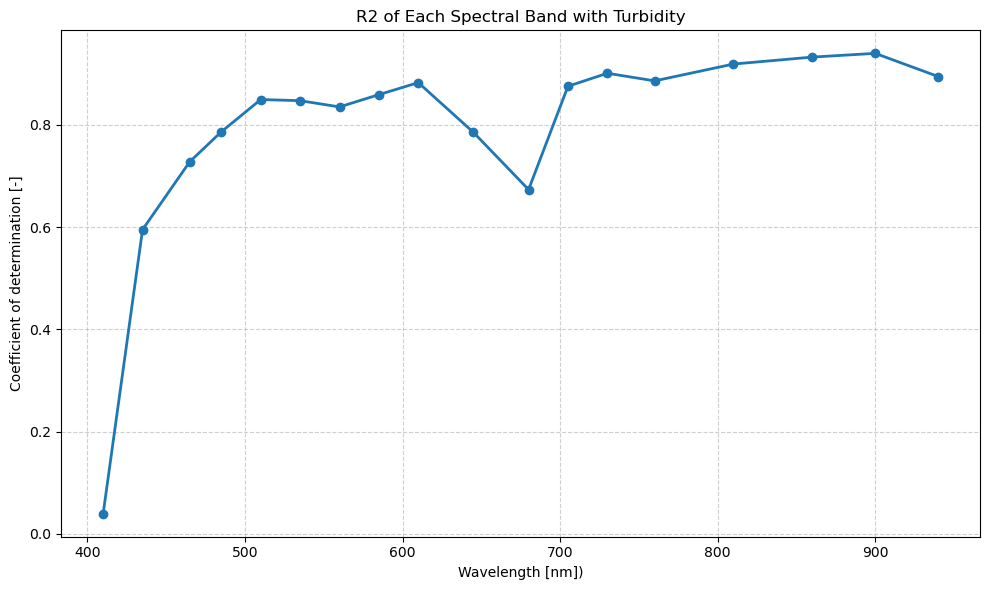

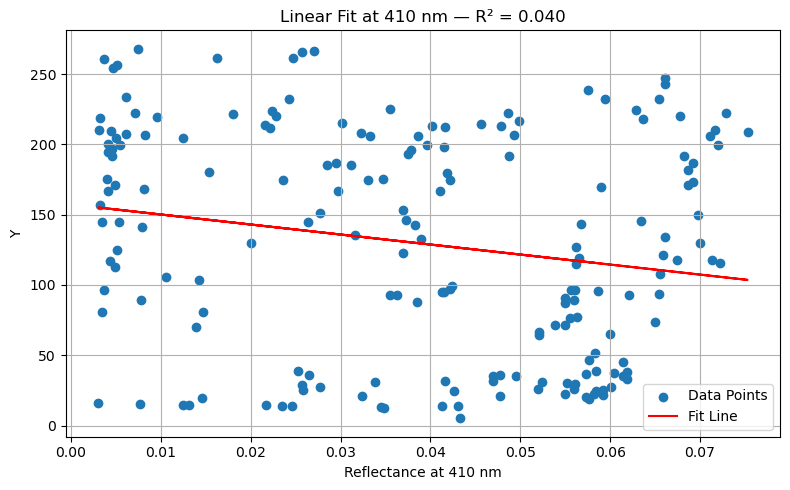

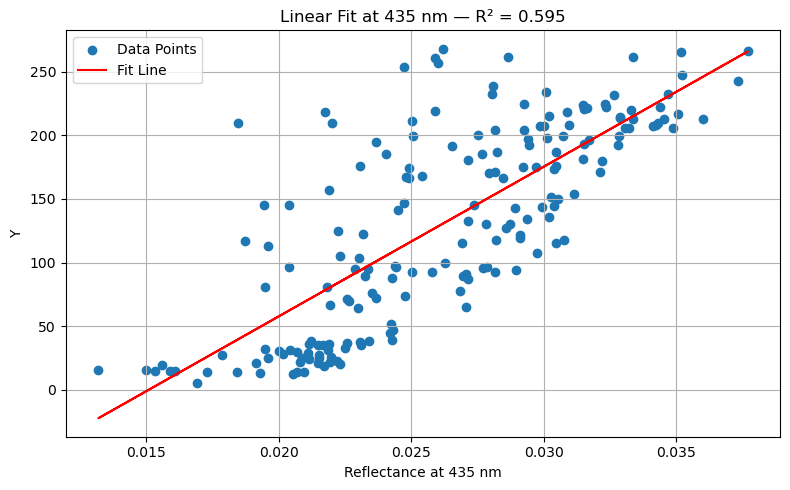

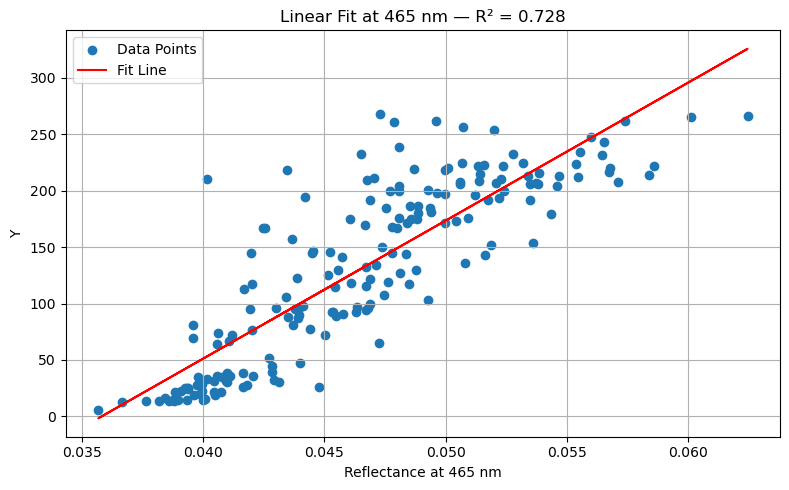

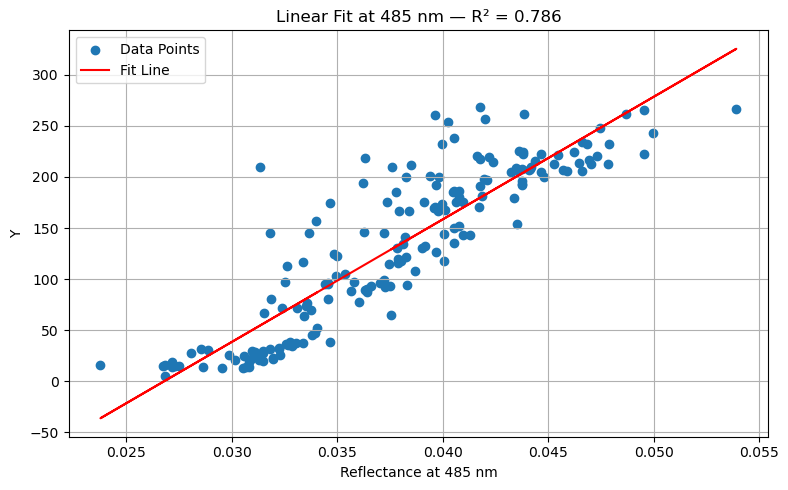

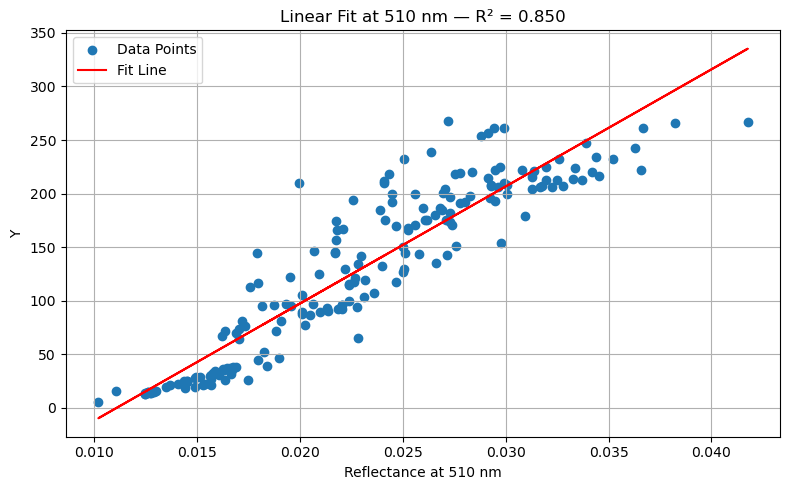

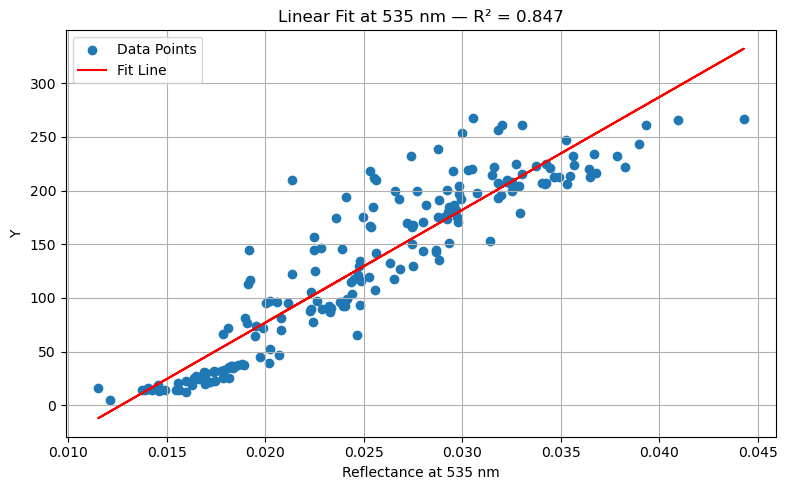

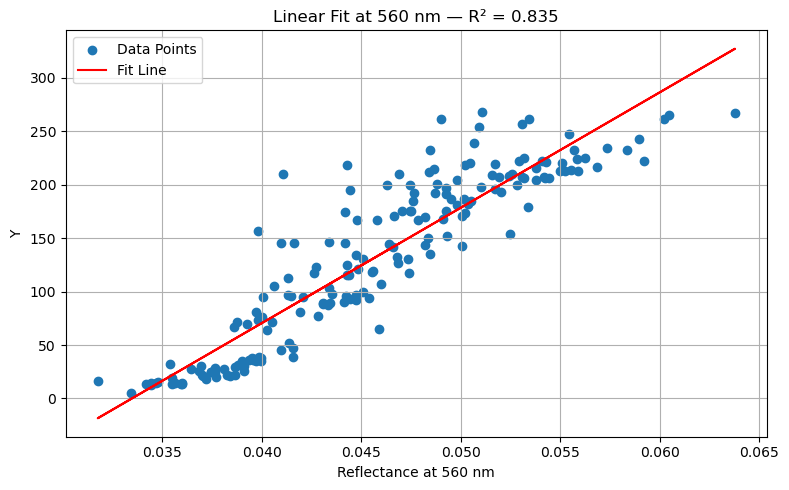

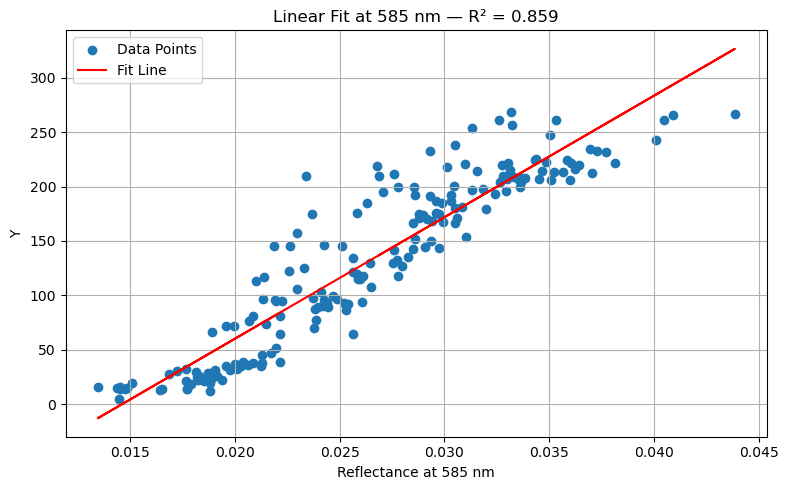

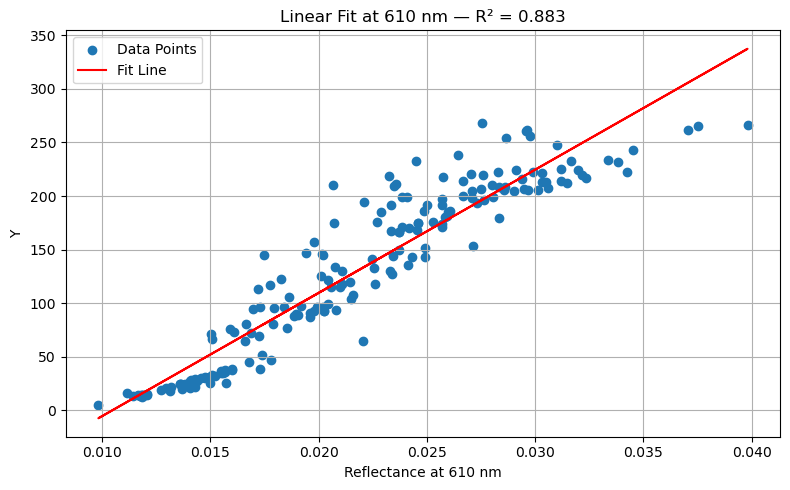

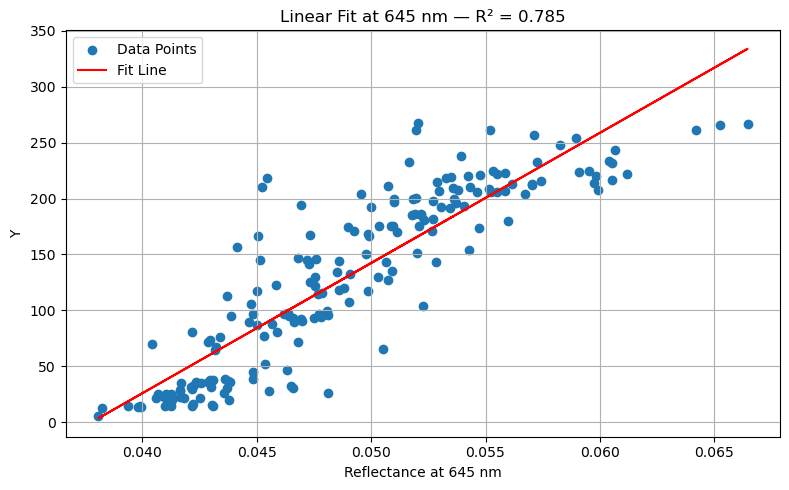

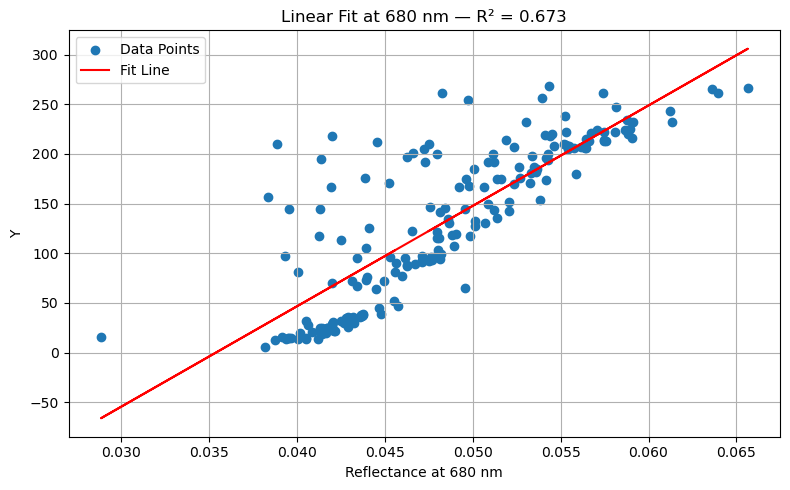

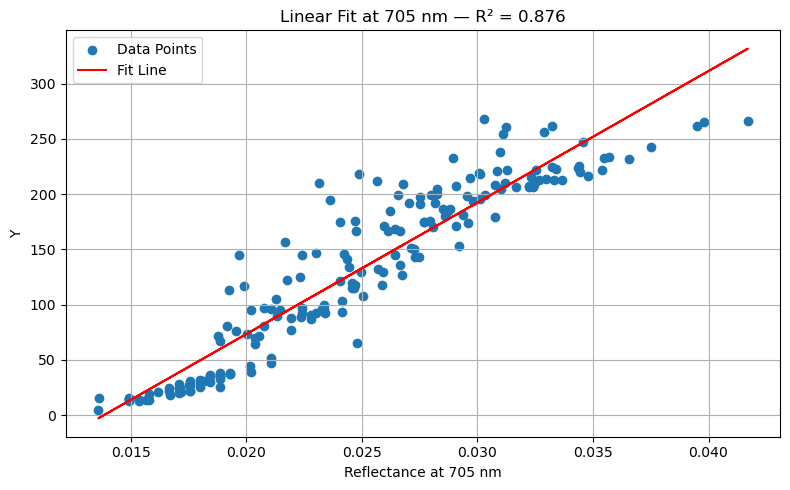

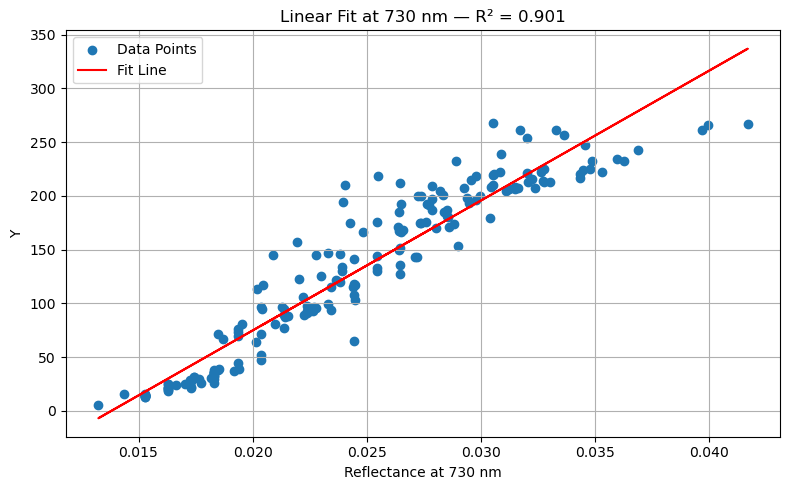

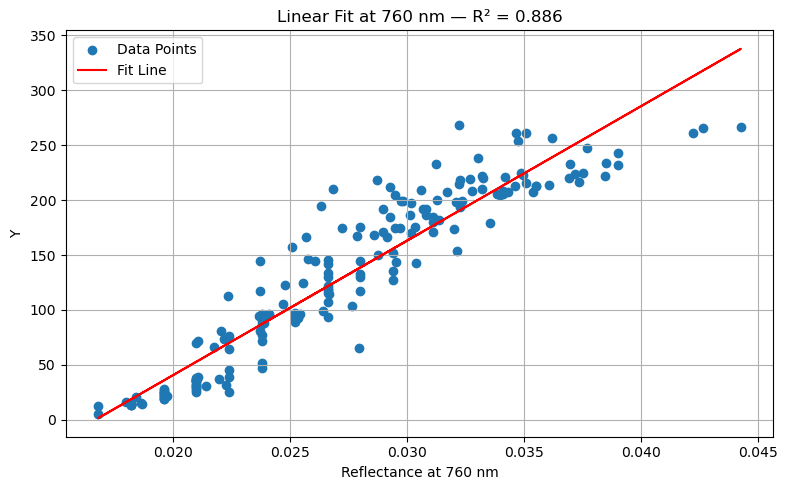

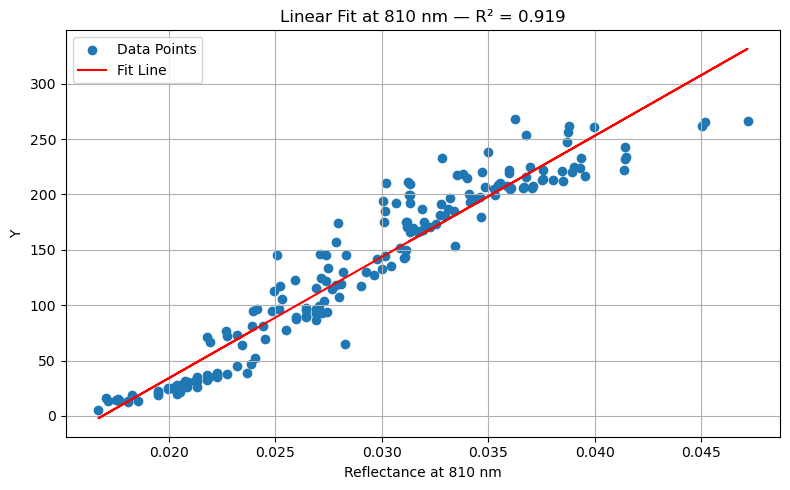

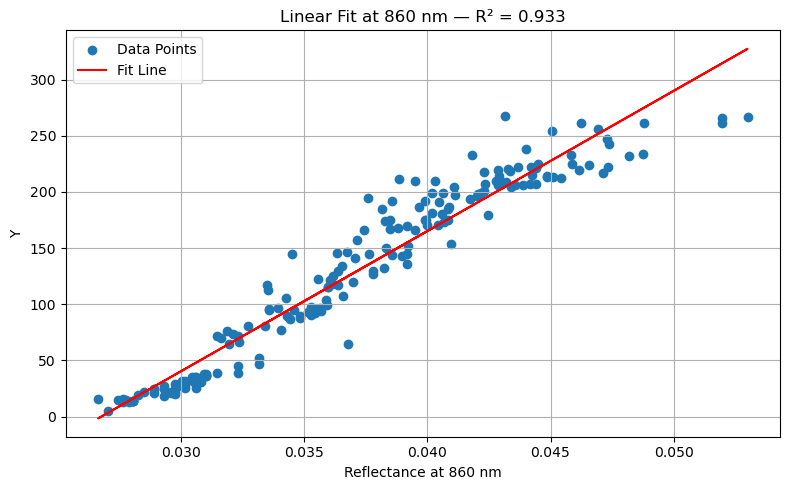

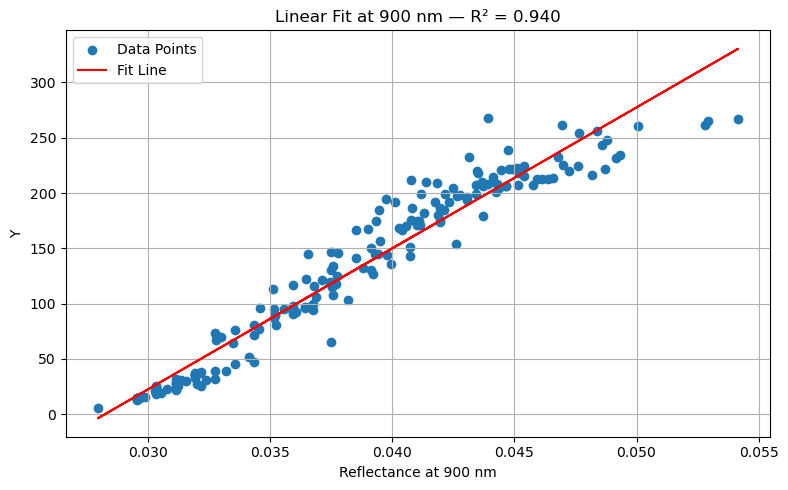

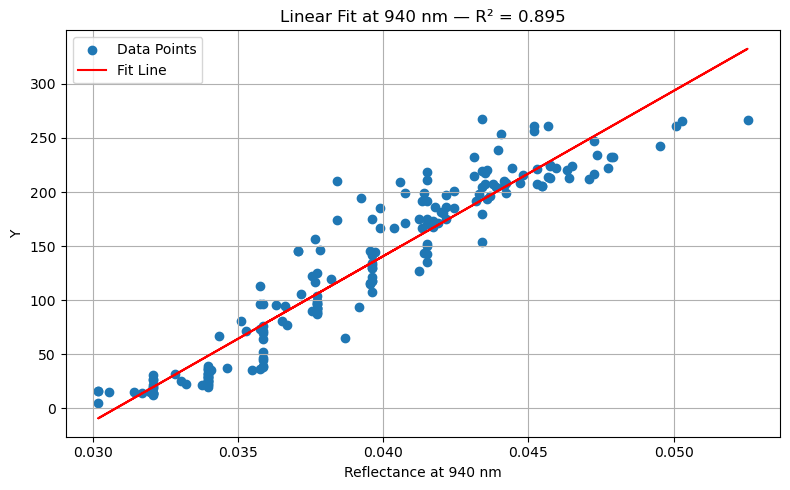

,Wavelength (nm),Pearson r,R²,Slope,Intercept,p-value
0,900,0.969503,0.939936,12756.826165,-360.379865,1.551662e-115
1,860,0.965717,0.932609,12480.767927,-333.981048,6.943852e-111
2,810,0.958647,0.919003,10947.055044,-184.872735,1.871207e-103
3,730,0.949234,0.901046,12071.388079,-166.639938,2.313722e-95
4,940,0.945821,0.894578,15286.492452,-470.769296,8.376106e-93
5,760,0.941325,0.886093,12249.919768,-204.412732,1.126820e-89
6,610,0.939551,0.882756,11494.140163,-120.232599,1.654627e-88
7,705,0.935719,0.875570,11891.035248,-164.344869,4.199235e-86
8,585,0.926935,0.859208,11169.392616,-163.261058,4.138457e-81
9,510,0.921732,0.849591,10926.547658,-121.079879,1.941649e-78


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress


# Your wavelength names for each column
wavelengths = [410, 435, 465, 485, 510, 535, 560, 585, 610, 645, 680,
               705, 730, 760, 810, 860, 900, 940]

# Step 1: Compute Pearson correlation for each column in X
correlations = []
for i in range(len(wavelengths)):
    corr = np.corrcoef(X_reflectance[:, i], Y)[0, 1]
    correlations.append(corr)

# Step 2: Find the column with the highest absolute correlation
best_idx = np.argmax(np.abs(correlations))
best_corr = correlations[best_idx]
best_wavelength = wavelengths[best_idx]

print(f"Best correlated wavelength: {best_wavelength} nm with correlation = {best_corr:.3f}")

# Step 4: Plot

# Assuming X, Y, and wavelengths are already defined
r_values = [np.corrcoef(X_reflectance[:, i], Y)[0, 1] for i in range(len(wavelengths))]
r2_values = [r**2 for r in r_values]

# Plot line chart
plt.figure(figsize=(10, 6))
plt.plot(wavelengths, r2_values, marker='o', linestyle='-', linewidth=2)
plt.xlabel('Wavelength [nm])')
plt.ylabel('Coefficient of determination [-]')
plt.title('R2 of Each Spectral Band with Turbidity')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Assuming X, Y, and wavelengths are already defined
for i, wl in enumerate(wavelengths):
    x_col = X_reflectance[:, i]
    slope, intercept, r_value, p_value, std_err = linregress(x_col, Y)
    r_squared = r_value**2

    # Plot for this wavelength
    plt.figure(figsize=(8, 5))
    plt.scatter(x_col, Y, label='Data Points')
    plt.plot(x_col, slope * x_col + intercept, color='red', label=f'Fit Line')
    plt.xlabel(f'Reflectance at {wl} nm')
    plt.ylabel('Y')
    plt.title(f'Linear Fit at {wl} nm — R² = {r_squared:.3f}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Store all stats in a list of dicts
results = []

for i, wl in enumerate(wavelengths):
    x_col = X_reflectance[:, i]
    slope, intercept, r_value, p_value, std_err = linregress(x_col, Y)
    results.append({
        'Wavelength (nm)': wl,
        'Pearson r': r_value,
        'R²': r_value**2,
        'Slope': slope,
        'Intercept': intercept,
        'p-value': p_value
    })

# Convert to DataFrame
df_results = pd.DataFrame(results)

# Optional: sort by R² descending
df_results_sorted = df_results.sort_values(by='R²', ascending=False).reset_index(drop=True)

# Display
import pandas as pd
from IPython.display import display
display(df_results_sorted)